In [1]:
import mdtraj as md
import numpy as np
import nglview as nv
import sys
sys.path.insert(0, '../../../src/')
from feature_maps import PlaneAlign, GramMatrixLayer

Let's pull the trajectory, align it and visualize it.

In [2]:
traj_location = 'alanine_vacuum_c98bd31af9274ccda0be95f45b0b2812'
traj = md.load(f'{traj_location}/traj_alanine_vacuum.dcd', top=f'alanine-dipeptide.pdb')

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


In [3]:
# align the trajectory to the first frame
traj.superpose(traj[0])
view = nv.show_mdtraj(traj)
view.center()
view
# view.display(gui=True)

NGLWidget(max_frame=49999)

Let's get ramchandrans: 

In [5]:
# list the atoms in the trajectory
for atom in traj.topology.atoms:
    print(atom.index, atom.name, atom.residue.name, atom.residue.index)

0 H1 ACE 0
1 CH3 ACE 0
2 H2 ACE 0
3 H3 ACE 0
4 C ACE 0
5 O ACE 0
6 N ALA 1
7 H ALA 1
8 CA ALA 1
9 HA ALA 1
10 CB ALA 1
11 HB1 ALA 1
12 HB2 ALA 1
13 HB3 ALA 1
14 C ALA 1
15 O ALA 1
16 N NME 2
17 H NME 2
18 C NME 2
19 H1 NME 2
20 H2 NME 2
21 H3 NME 2


In [6]:
(phi_idx, phi), (psi_idx, psi) = md.compute_phi(traj), md.compute_psi(traj)

In [7]:
print(f'{phi_idx}, {phi.shape}')
print(f'{psi_idx}, {psi.shape}')


[[ 4  6  8 14]], (50000, 1)
[[ 6  8 14 16]], (50000, 1)


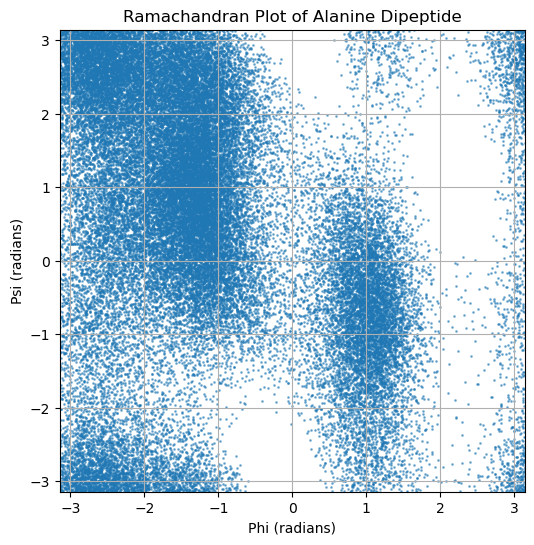

In [8]:
# now scatter them to see the Ramachandran plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(phi[:,0], psi[:,0], s=1, alpha=0.5) 
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.xlabel('Phi (radians)')
plt.ylabel('Psi (radians)')
plt.title('Ramachandran Plot of Alanine Dipeptide')
plt.grid()
plt.show()


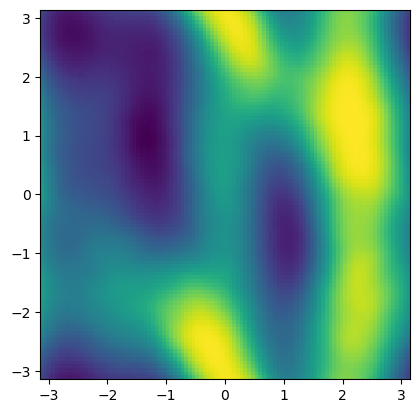

In [10]:
free_energy = np.load(f'{traj_location}/free_energy.npz', allow_pickle=True)
free_energy = free_energy['free_energy']
plt.imshow(free_energy, extent=(-np.pi, np.pi, -np.pi, np.pi), origin='lower', cmap='viridis')

In [22]:
# load trajectory as numpy array 
import torch
traj_array = torch.flatten(torch.tensor(traj.xyz), start_dim=1)  # shape (n_frames, n_atoms, 3)

In [23]:
feature_map = PlaneAlign(atoms=[4,8,16])  # CA, N, C atoms
features = feature_map.forward(traj_array).numpy()[::5, :]

In [32]:
# get pca 
from sklearn.decomposition import PCA, KernelPCA
pca = KernelPCA(n_components=10, kernel='rbf', gamma=1e-3)
pca_result = pca.fit_transform(features)

In [ ]:
from diffusion_map import DiffusionMap
diff_map = DiffusionMap(alpha=1.0, epsilon=1.0, num_evecs=10)

Text(0.5, 0.92, 'PCA of Alanine Dipeptide Features')

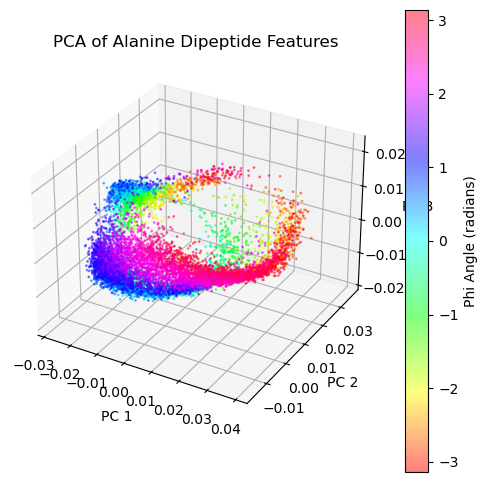

In [34]:
# plot prinicpal components
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')
s = ax.scatter(pca_result[:,0], pca_result[:,1], pca_result[:,2], c=psi[::5], s=1, alpha=0.5, cmap='hsv') 
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
fig.colorbar(s, label='Phi Angle (radians)')
plt.title('PCA of Alanine Dipeptide Features')